Hybrid approach ( Summarization + Trimming )

To solve the problem of losing context of previous messages in trimming , we uses summarzation. Suppose there were 500 messages and context window is exceeding. To keep under context window , we will use this hybrid approach. We will make a summary of 400 messages by giving to an LLM and inject it with recent N messages of trimming. So our LLM will not lose the context. This time we delete the previous messages ( using langgraph RemoveMessages) because we are already storing them in sumamry

In [25]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START , END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately

In [26]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

class ChatState(MessagesState):
    summary : str

In [27]:
def chat_node(state: ChatState):

    messages = []

    summary = state.get('summary' , '')
    if summary: ## it will check whether summary generated in chat till yet or not . if generated then append in the messages as System message
        messages.append({
            "role": "system",
            "content": f"Conversation summary so far:\n{summary}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = llm.invoke(messages)
    return {"messages": [response]}

In [28]:
TOKEN_LIMIT = 50

def should_summarize(state: ChatState):
    total_tokens = count_tokens_approximately(messages=state['messages'])
    print(f"Current tokens: {total_tokens} / {TOKEN_LIMIT}")
    return total_tokens > TOKEN_LIMIT

In [29]:
def summarize_conversation(state: ChatState):

    existing_summary = state.get('summary' , '')

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete], ## this will delete the previous messages after generating the summary
    }

In [30]:
builder = StateGraph(ChatState)
builder.add_node('chat_node' , chat_node)
builder.add_node('summarize_conversation' , summarize_conversation)

builder.add_edge(START , 'chat_node')

builder.add_conditional_edges(
    "chat_node",
    should_summarize,
    {
        True: "summarize_conversation",
        False: END,
    }
)

builder.add_edge("summarize_conversation", END)
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

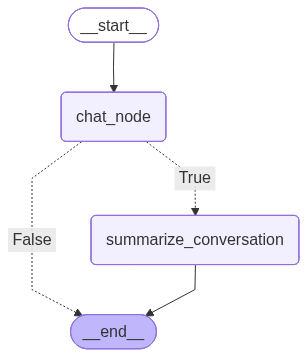

In [31]:
graph

In [32]:
config = {"configurable": {"thread_id": "t1"}}

In [33]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

In [34]:
graph.invoke({"messages": [HumanMessage(content='Hi My name is imran')]}, config=config)
show_state()

[HumanMessage(content='Hi My name is imran', additional_kwargs={}, response_metadata={}, id='c48b0a90-b522-4ba0-b7bb-be3146fcb981')]
Current tokens: 29 / 50

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Hi My name is imran
- AIMessage : Hi Imran! It's nice to meet you. How can I help you today?


In [35]:
graph.invoke({"messages": [HumanMessage(content='I am learning langgraph')]}, config=config)
show_state()

[HumanMessage(content='Hi My name is imran', additional_kwargs={}, response_metadata={}, id='c48b0a90-b522-4ba0-b7bb-be3146fcb981'), AIMessage(content="Hi Imran! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e4507-b9d8-7e30-be5a-5938015fca2e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 18, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='I am learning langgraph', additional_kwargs={}, response_metadata={}, id='c2b6baac-6ca9-400d-9b3e-bbcca5c58241')]
Current tokens: 340 / 50

--- STATE ---
summary: The conversation started with you introducing yourself as Imran and stating that you are learning LangGraph. I responded by acknowledging your name, expressing enthusiasm for your learning journey, and offering various ways I can

In [36]:
graph.invoke({"messages": [HumanMessage(content='Can you tell me what is short term memory')]}, config=config)
show_state()

[{'role': 'system', 'content': "Conversation summary so far:\nThe conversation started with you introducing yourself as Imran and stating that you are learning LangGraph. I responded by acknowledging your name, expressing enthusiasm for your learning journey, and offering various ways I can assist you, such as explaining concepts, providing examples, debugging, suggesting resources, or brainstorming project ideas. I then asked you what you'd like to focus on next."}, HumanMessage(content='I am learning langgraph', additional_kwargs={}, response_metadata={}, id='c2b6baac-6ca9-400d-9b3e-bbcca5c58241'), AIMessage(content="That's fantastic, Imran! LangGraph is a powerful tool for building stateful, multi-agent applications. It's a great choice for learning if you're interested in creating more complex and interactive AI workflows.\n\nTo help you learn LangGraph effectively, I can assist you in a few ways. Tell me, what are you hoping to achieve with LangGraph, or what aspects are you findi

In [37]:
graph.invoke({"messages": [HumanMessage(content='What is my name ??')]}, config=config)
show_state()

[{'role': 'system', 'content': 'Conversation summary so far:\nExisting summary:\nThe conversation started with you introducing yourself as Imran and stating that you are learning LangGraph. I responded by acknowledging your name, expressing enthusiasm for your learning journey, and offering various ways I can assist you, such as explaining concepts, providing examples, debugging, suggesting resources, or brainstorming project ideas. I then asked you what you\'d like to focus on next.\n\nExtended Summary:\nThe conversation started with you introducing yourself as Imran and stating that you are learning LangGraph. I responded by acknowledging your name, expressing enthusiasm for your learning journey, and offering various ways I can assist you, such as explaining concepts, providing examples, debugging, suggesting resources, or brainstorming project ideas. I then asked you what you\'d like to focus on next. **You then asked for an explanation of "short-term memory" in the context of AI a